# XGBoost 2026 heatwave regression for Zennevallei

This notebook is the readable source for the **2026 Heatwave XGBoost** method in the land-cover change tool. It predicts the daytime **land-surface temperature (LST)** measured by Landsat over Zennevallei on 22 June 2026. It does not predict air temperature, human heat exposure, causality, or a future heatwave.

The code below deliberately follows the data in a straight line. Small production helpers are reused only where doing the work differently here could make training and the live scenario disagree.

In [1]:
from pathlib import Path
from io import BytesIO
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import numpy as np
import pandas as pd
from PIL import Image
from pyproj import Transformer
import requests

PROJECT_ROOT = Path.cwd()
PACKAGE_ROOT = PROJECT_ROOT / 'processing' / 'local-layers' / 'src'
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

# Set this to True only when you intentionally want to run the full 50-trial search.
RUN_FULL_TUNING = False
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

In [2]:
from greenwave_local_layers.image_regression import (
    ImageRegressionDataset, LAND_COVER_CHANNEL_NAMES, SUPPORT_MASK,
    prepare_regression_catalog, radial_band_fractions,
)
from greenwave_local_layers.image_regression_optuna import (
    FEATURES_PATH, NOTEBOOK_DIAGNOSTICS_PATH, PREDICTIONS_PATH,
    REPORT_OUTPUT_PATH, STUDY_PATH,
    build_optuna_folds, completed_trials, create_or_load_study,
    extract_optuna_features, optimise, prepare_notebook_diagnostics,
    select_smoothing_example_sector,
)
from greenwave_local_layers.image_regression_xgboost_pipeline import (
    DEFAULT_ARTIFACTS, FEATURE_CONTRACT_VERSION,
    FEATURE_REMOVAL_TOLERANCE_C, radial_feature_names,
)
from greenwave_local_layers.sources import file_hash

print('Feature contract:', FEATURE_CONTRACT_VERSION)

c:\Users\Necro\Documents\Greenwave\processing\local-layers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature contract: 5


## 1. Start with the raw inputs

The target is one clear Landsat Collection 2 surface-temperature acquisition. The predictors are mapped land cover around the same 30 m locations: Soil sealing 2024, Green Map 2021, and an additive water mask that keeps Urban Atlas 2021 water and adds Flanders Land Use 2025 class 17. Flanders water is moved from its native 10 m grid to the 1 m predictor grid with nearest-neighbour assignment and takes priority over every other category. Their years differ from the target year, which is an important limitation.

`lst_c` is the scaled Landsat surface-temperature target. `uncertainty_k` is Landsat's scaled ST_QA uncertainty, while `snap_offset_m` is calculated here as the distance to the nearest 1 m predictor-grid centre. The latter two are quality-control metadata, not XGBoost features or weights.

In [3]:
catalog = prepare_regression_catalog('landsat-2026-06-22')
samples = catalog.samples.copy()

source_rows = []
for name, source in catalog.manifest['sources'].items():
    source_rows.append({
        'input': name,
        'file': source['path'],
        'size_mb': round(source['size'] / 1_000_000, 1),
        'sha256_start': source['sha256'][:12],
    })
display(pd.DataFrame(source_rows))
water_audit = catalog.manifest['analysisWater']['audit']
display(pd.DataFrame([
    {'water source relationship': 'Urban Atlas-only', 'area_ha': water_audit['urbanAtlasOnlyHa']},
    {'water source relationship': 'Flanders-only', 'area_ha': water_audit['landUseOnlyHa']},
    {'water source relationship': 'Both sources', 'area_ha': water_audit['intersectionHa']},
    {'water source relationship': 'Additive union used by XGBoost', 'area_ha': water_audit['unionHa']},
]))
print(f"Eligible observations: {len(samples):,}")
print(f"Statbel sectors: {samples['sector_id'].nunique()}")
display(samples[['lst_c', 'uncertainty_k', 'snap_offset_m']].describe().round(3))

,input,file,size_mb,sha256_start
0,landsat,.cache/local-layers/landsat-temperature/analys...,1.8,a5e73a381360
1,soilSealing,.cache/local-layers/density-source/jaarbak/jaa...,5.7,3b95eec9999c
2,greenMap,.cache/local-layers/density-source/groenkaart/...,10.4,04b3d82887cb
3,sectors,public/data/sectors.geojson,1.1,6c37e0d0e811
4,urbanAtlas,.cache/urban-atlas/CLMS_UA_LCU_S2021_V025ha_BE...,178.9,3c55e3ee31ac
5,urbanContext,.cache/local-layers/image-regression/shared/ur...,4.4,d6a1bb92466b
6,landUseWater,.cache/local-layers/raw/landgebruik/landgebrui...,0.4,d3b7255e3c2a
7,waterContext,.cache/local-layers/image-regression/shared/an...,0.3,dea3cda8c8ed


,water source relationship,area_ha
0,Urban Atlas-only,38.0277
1,Flanders-only,122.5284
2,Both sources,70.8871
3,Additive union used by XGBoost,231.4432


Eligible observations: 192,595
Statbel sectors: 154


,lst_c,uncertainty_k,snap_offset_m
count,192595.000,192595.000,192595.000
mean,30.562,3.573,0.383
std,3.984,0.763,0.142
min,12.653,2.540,0.000
25%,28.283,3.080,0.282
50%,30.239,3.460,0.399
75%,32.628,3.810,0.489
max,50.955,12.820,0.707


## 2. Look at the value we want to predict

Every point below is one eligible 30 m Landsat centre. The map is only a diagnostic picture; the model is validated with whole sectors held out later.

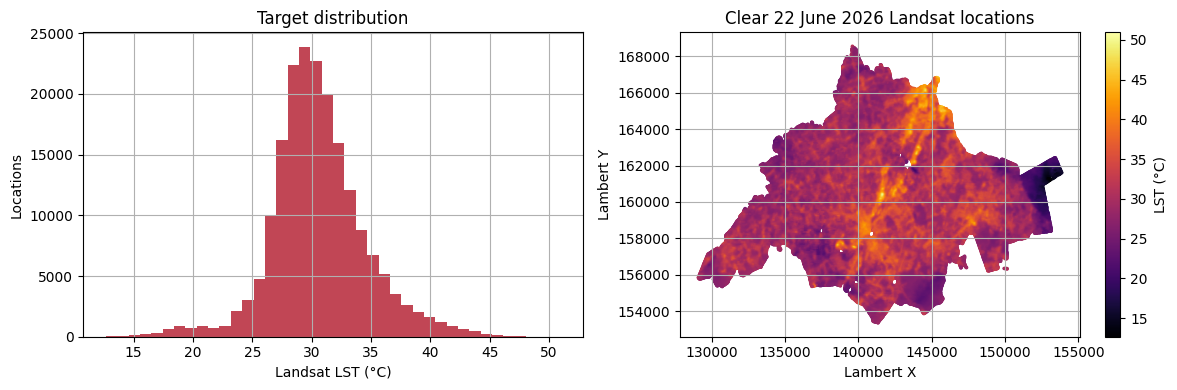

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(samples['lst_c'], bins=40, color='#b2182b', alpha=.8)
axes[0].set(xlabel='Landsat LST (°C)', ylabel='Locations', title='Target distribution')
points = axes[1].scatter(
    samples['x_lambert'], samples['y_lambert'], c=samples['lst_c'],
    s=2, cmap='inferno', rasterized=True,
)
axes[1].set(title='Clear 22 June 2026 Landsat locations', xlabel='Lambert X', ylabel='Lambert Y')
figure.colorbar(points, ax=axes[1], label='LST (°C)')
plt.tight_layout()
plt.show()

## 3. Turn one 200 m neighbourhood into model inputs

Green Map is categorical, so High and Low vegetation cannot occupy the same source pixel. We also resolve High vegetation above any latent Low or sealed ground before modelling. The five displayed channels are therefore a mutually exclusive upper surface. Other unsealed land is the implicit remainder.

,example,sample,sector,municipality,LST (°C),Landsat uncertainty (K),snap offset (m)
0,Low LST (10th percentile),landsat-2026-06-22:133:364,23077D091,Sint-Pieters-Leeuw,26.52,2.72,0.46
1,Median LST (50th percentile),landsat-2026-06-22:113:389,23077A09-,Sint-Pieters-Leeuw,30.24,3.13,0.57
2,High LST (90th percentile),landsat-2026-06-22:153:466,23077A30-,Sint-Pieters-Leeuw,35.51,3.37,0.46


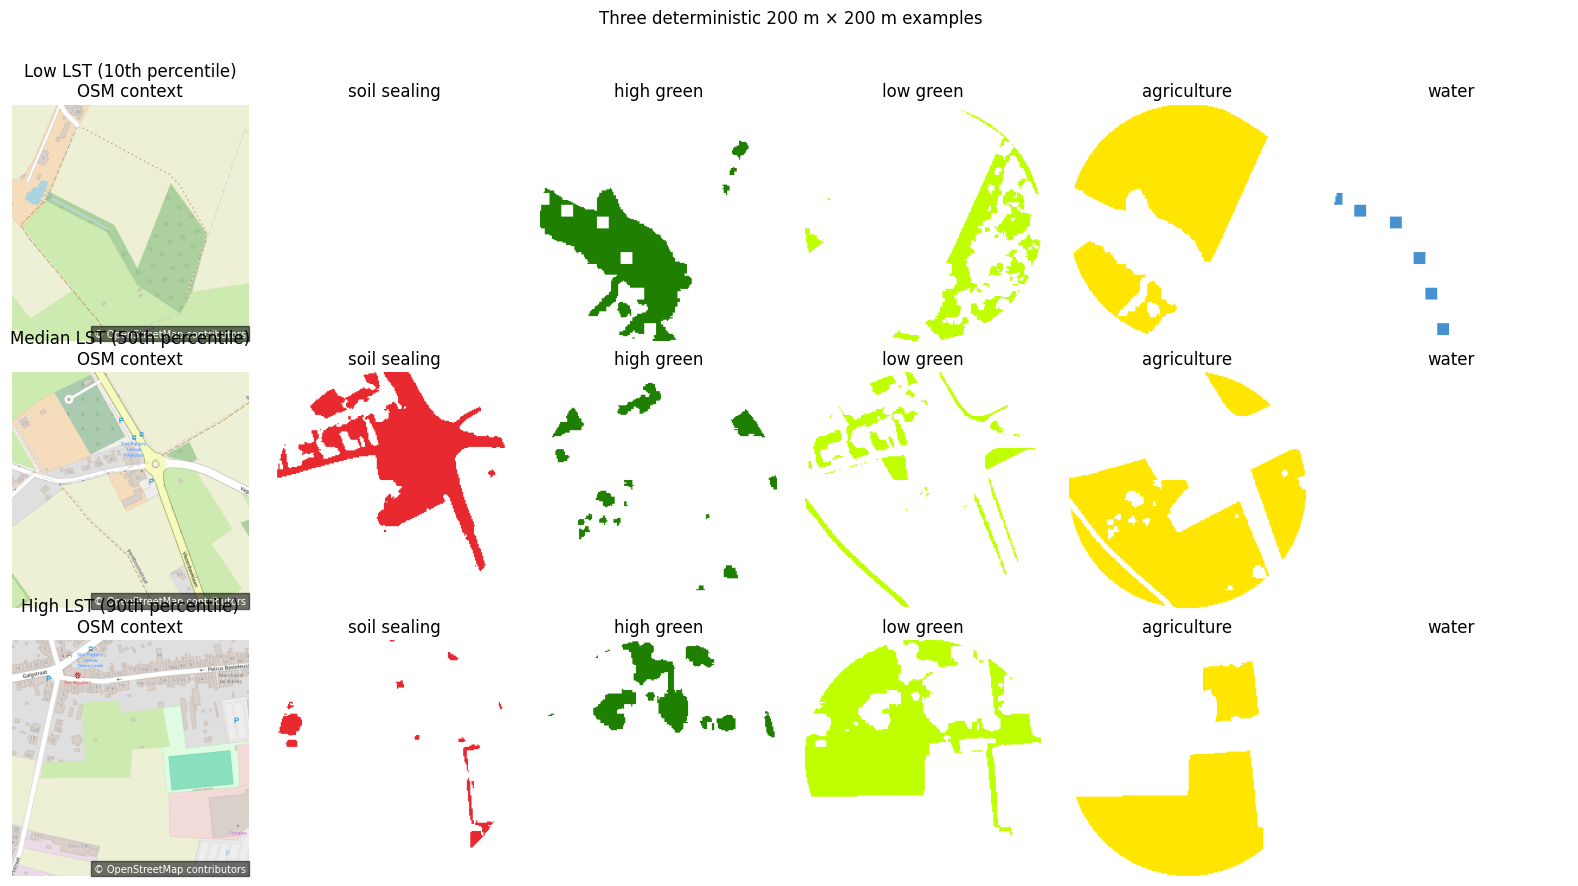

In [5]:
CATEGORY_COLORS = {
    'soil_sealing': '#e8292f',
    'high_green': '#1f7f00',
    'low_green': '#bfff00',
    'agriculture': '#ffe600',
    'water': '#4691d0',
}
OSM_CACHE = PROJECT_ROOT / '.cache' / 'notebook-osm'
OSM_CACHE.mkdir(parents=True, exist_ok=True)
to_wgs84 = Transformer.from_crs('EPSG:31370', 'EPSG:4326', always_xy=True)

def osm_context_image(x, y, zoom=17):
    """Return a cached 512 px OSM image; failure is visible but non-fatal."""
    longitude, latitude = to_wgs84.transform(float(x), float(y))
    scale = 2 ** zoom
    tile_x = (longitude + 180.0) / 360.0 * scale
    tile_y = (1.0 - math.asinh(math.tan(math.radians(latitude))) / math.pi) / 2.0 * scale
    centre_x, centre_y = int(math.floor(tile_x)), int(math.floor(tile_y))
    mosaic = Image.new('RGB', (768, 768), '#eeeeee')
    try:
        for row_offset in (-1, 0, 1):
            for column_offset in (-1, 0, 1):
                tile_column = centre_x + column_offset
                tile_row = centre_y + row_offset
                tile_path = OSM_CACHE / f'{zoom}-{tile_column}-{tile_row}.png'
                if not tile_path.exists():
                    response = requests.get(
                        f'https://tile.openstreetmap.org/{zoom}/{tile_column}/{tile_row}.png',
                        headers={'User-Agent': 'Greenwave-Zennevallei-XGBoost-notebook/1.0'},
                        timeout=20,
                    )
                    response.raise_for_status()
                    tile_path.write_bytes(response.content)
                with Image.open(tile_path) as tile:
                    mosaic.paste(tile.convert('RGB'), ((column_offset + 1) * 256, (row_offset + 1) * 256))
        pixel_x = 256 + (tile_x - centre_x) * 256
        pixel_y = 256 + (tile_y - centre_y) * 256
        return mosaic.crop((pixel_x - 256, pixel_y - 256, pixel_x + 256, pixel_y + 256))
    except (OSError, requests.RequestException):
        return None

dataset = ImageRegressionDataset(catalog)
used_sectors = set()
examples = []
for label, quantile in [('Low LST (10th percentile)', .10), ('Median LST (50th percentile)', .50), ('High LST (90th percentile)', .90)]:
    target_temperature = float(samples['lst_c'].quantile(quantile))
    candidates = samples.loc[~samples['sector_id'].astype(str).isin(used_sectors)].copy()
    candidates['distance_to_percentile'] = (candidates['lst_c'] - target_temperature).abs()
    chosen = candidates.sort_values(['distance_to_percentile', 'sample_id'], kind='stable').iloc[0]
    sample_number = int(chosen.name)
    patch = dataset.land_cover_patch(sample_number)
    assert np.all(patch.sum(axis=0)[SUPPORT_MASK] <= 1), 'Upper-surface classes overlap.'
    examples.append({'label': label, 'sample': chosen, 'patch': patch})
    used_sectors.add(str(chosen['sector_id']))
dataset.close()
assert len(examples) == 3 and len(used_sectors) == 3

display(pd.DataFrame([{
    'example': example['label'],
    'sample': example['sample']['sample_id'],
    'sector': example['sample']['sector_id'],
    'municipality': example['sample']['municipality'],
    'LST (°C)': round(float(example['sample']['lst_c']), 2),
    'Landsat uncertainty (K)': round(float(example['sample']['uncertainty_k']), 2),
    'snap offset (m)': round(float(example['sample']['snap_offset_m']), 2),
} for example in examples]))

figure, axes = plt.subplots(3, 6, figsize=(16, 9))
for row, example in enumerate(examples):
    sample, patch = example['sample'], example['patch']
    osm_image = osm_context_image(sample['x_lambert'], sample['y_lambert'])
    if osm_image is None:
        axes[row, 0].set_facecolor('#eeeeee')
        axes[row, 0].text(.5, .5, 'OSM context unavailable', ha='center', va='center', transform=axes[row, 0].transAxes)
    else:
        axes[row, 0].imshow(osm_image)
    axes[row, 0].set_title(f"{example['label']}\nOSM context")
    axes[row, 0].text(.99, .01, '© OpenStreetMap contributors', ha='right', va='bottom', fontsize=7, color='white', bbox={'facecolor': 'black', 'alpha': .55, 'pad': 2}, transform=axes[row, 0].transAxes)
    axes[row, 0].axis('off')
    for column, (name, image) in enumerate(zip(LAND_COVER_CHANNEL_NAMES, patch), start=1):
        axes[row, column].imshow(image, cmap=ListedColormap(['#ffffff', CATEGORY_COLORS[name]]), vmin=0, vmax=1)
        axes[row, column].set_title(name.replace('_', ' '))
        axes[row, column].axis('off')
plt.suptitle('Three deterministic 200 m × 200 m examples')
plt.tight_layout(rect=(0, 0, 1, .96))
plt.show()

## 4. Summarise distance from the centre

The model does not receive 40,000 raw pixels. For each class it receives the covered fraction in rings around the Landsat centre. Optuna tests ring widths of 5, 10, 20, 25 and 50 m. This small example uses 25 m rings.

Low LST (10th percentile) — 23077D091


,0–25 m,25–50 m,50–75 m,75–100 m
soil_sealing,0.000,0.000,0.000,0.000
high_green,0.266,0.370,0.260,0.132
low_green,0.000,0.134,0.132,0.185
agriculture,0.734,0.448,0.436,0.482
water,0.000,0.031,0.015,0.017


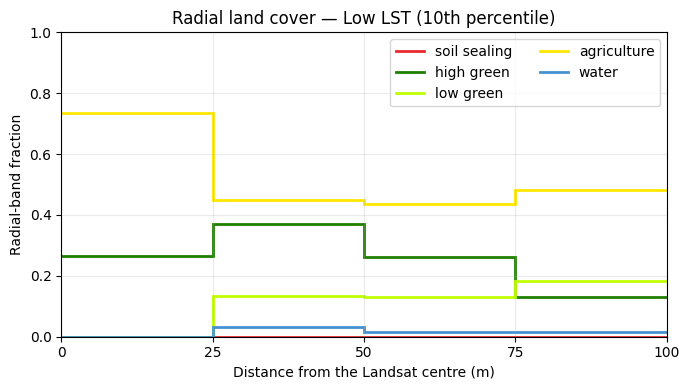

Median LST (50th percentile) — 23077A09-


,0–25 m,25–50 m,50–75 m,75–100 m
soil_sealing,0.681,0.450,0.334,0.177
high_green,0.009,0.033,0.032,0.085
low_green,0.046,0.065,0.104,0.138
agriculture,0.219,0.437,0.514,0.562
water,0.000,0.000,0.000,0.000


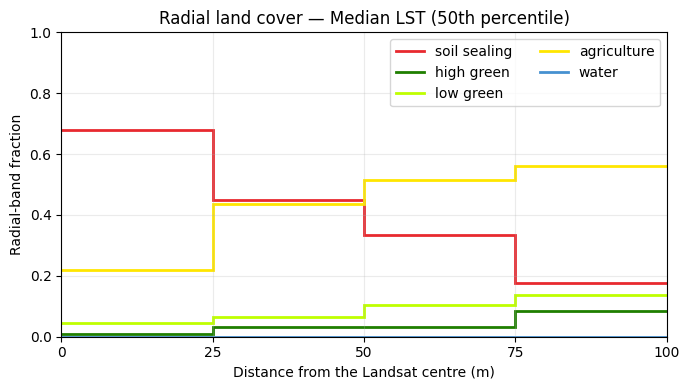

High LST (90th percentile) — 23077A30-


,0–25 m,25–50 m,50–75 m,75–100 m
soil_sealing,0.003,0.002,0.020,0.045
high_green,0.000,0.118,0.132,0.071
low_green,0.636,0.478,0.329,0.360
agriculture,0.271,0.369,0.459,0.356
water,0.000,0.000,0.000,0.000


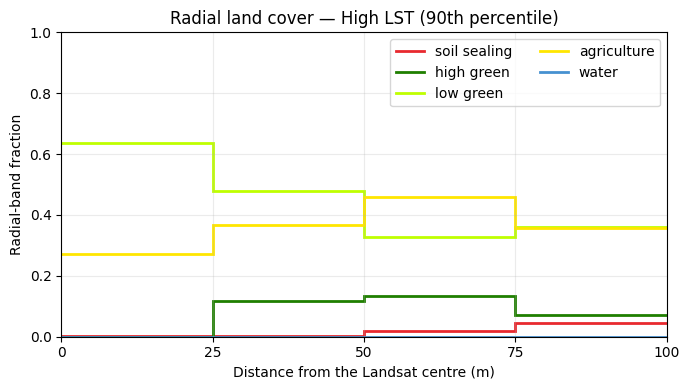

In [6]:
ring_labels = ['0–25 m', '25–50 m', '50–75 m', '75–100 m']
ring_edges = [0, 25, 50, 75, 100]
for example in examples:
    sample_features = radial_band_fractions(example['patch'], SUPPORT_MASK)
    print(f"{example['label']} — {example['sample']['sector_id']}")
    display(pd.DataFrame(sample_features, index=LAND_COVER_CHANNEL_NAMES, columns=ring_labels).round(3))
    figure, axis = plt.subplots(figsize=(7, 4))
    for category, fractions in zip(LAND_COVER_CHANNEL_NAMES, sample_features):
        axis.stairs(fractions, ring_edges, baseline=None, color=CATEGORY_COLORS[category], linewidth=2, label=category.replace('_', ' '))
    axis.set(
        xlabel='Distance from the Landsat centre (m)',
        ylabel='Radial-band fraction',
        title=f"Radial land cover — {example['label']}",
        xlim=(0, 100),
        ylim=(0, 1),
    )
    axis.set_xticks([0, 25, 50, 75, 100])
    axis.grid(alpha=.25)
    axis.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 5. Build all features and spatial folds

A random row split would leak nearby landscapes. All observations from a Statbel sector go to the same fold. Training locations within 200 m of a held-out sector are excluded, so the two 100 m predictor supports cannot touch.

In [7]:
feature_matrices, targets, names_by_width = extract_optuna_features(catalog)
folds = build_optuna_folds(samples)

print('Rows:', f'{len(targets):,}')
for width in sorted(feature_matrices):
    print(f'{width:>2} m rings: {feature_matrices[width].shape[1]} features')
fold_table = pd.DataFrame([{'fold': fold.fold, **fold.diagnostics} for fold in folds])
display(fold_table)

Rows: 192,595
 5 m rings: 100 features
10 m rings: 50 features
20 m rings: 25 features
25 m rings: 20 features
50 m rings: 10 features


,fold,trainSampleCount,testSampleCount,excludedBufferSampleCount,trainSectorCount,testSectorCount,trainMunicipalities,testMunicipalities,bufferMeters
0,0,126100,38520,27975,122,30,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Halle, Linkebeek, Pepingen, Sint-Gen...",200.0
1,1,128690,38515,25390,122,31,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
2,2,127778,38512,26305,121,31,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
3,3,128433,38522,25640,119,31,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
4,4,130320,38526,23749,119,31,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Pepingen, Sint-Gen...",200.0


## 6. Tune the model

One Optuna trial chooses every item below, trains on each of the five spatial folds, and returns the pooled held-out RMSE. The search is seeded with 42 and completes exactly 50 successful trials. Early stopping can stop before the 3,000-round maximum.

In [8]:
parameter_ranges = pd.DataFrame([
    ['ring_width_meters', 'choice', '5, 10, 20, 25, 50'],
    ['smoothing_sigma_meters', 'choice', '0, 15, 30, 45, 60'],
    ['learning_rate', 'log-uniform', '0.01 to 0.20'],
    ['max_depth', 'integer', '2 to 8'],
    ['min_child_weight', 'log-uniform', '1 to 32'],
    ['subsample', 'uniform', '0.60 to 1.00'],
    ['colsample_bytree', 'uniform', '0.50 to 1.00'],
    ['gamma', 'uniform', '0 to 5'],
    ['reg_alpha', 'log-uniform', '1e-8 to 10'],
    ['reg_lambda', 'log-uniform', '1e-3 to 30'],
], columns=['parameter', 'sampling', 'tested range'])
display(parameter_ranges)

,parameter,sampling,tested range
0,ring_width_meters,choice,"5, 10, 20, 25, 50"
1,smoothing_sigma_meters,choice,"0, 15, 30, 45, 60"
2,learning_rate,log-uniform,0.01 to 0.20
3,max_depth,integer,2 to 8
4,min_child_weight,log-uniform,1 to 32
5,subsample,uniform,0.60 to 1.00
6,colsample_bytree,uniform,0.50 to 1.00
7,gamma,uniform,0 to 5
8,reg_alpha,log-uniform,1e-8 to 10
9,reg_lambda,log-uniform,1e-3 to 30


In [9]:
study = create_or_load_study(STUDY_PATH)
if RUN_FULL_TUNING:
    study = optimise(
        study, feature_matrices, targets, samples, names_by_width, folds,
        trials=50, device='cuda',
    )

finished = completed_trials(study)
print(f'Completed trials: {finished}/50')
if finished < 50:
    print('Set RUN_FULL_TUNING=True, or run: pnpm lst-scenario:xgboost-optuna')
else:
    print('Best pooled spatial RMSE:', round(float(study.best_value), 3), '°C')
    display(pd.Series(study.best_trial.params, name='best value').to_frame())

[I 2026-08-14 12:21:20,604] Using an existing study with name 'zennevallei-xgboost-2026-exclusive-upper-surface-water-v5' instead of creating a new one.


Completed trials: 50/50
Best pooled spatial RMSE: 2.326 °C


,best value
ring_width_meters,5.000000e+00
smoothing_sigma_meters,6.000000e+01
learning_rate,2.954001e-02
max_depth,8.000000e+00
min_child_weight,1.432327e+00
subsample,7.041067e-01
colsample_bytree,8.995836e-01
gamma,4.146421e+00
reg_alpha,9.458117e-08
reg_lambda,1.222662e+00


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,...,params_ring_width_meters,params_smoothing_sigma_meters,params_subsample,user_attrs_device,user_attrs_duration_seconds,user_attrs_folds,user_attrs_mae_c,user_attrs_mean_error_c,user_attrs_r2,state
25,25,2.326463,2026-08-14 11:03:03.940992,2026-08-14 11:03:13.858663,0 days 00:00:09.917671,0.899584,4.146421,0.029540,8,1.432327,...,5,60,0.704107,cuda,9.905280,"[{'fold': 0, 'position': 0, 'bestRound': 197, ...",1.799950,-0.008509,0.659072,COMPLETE
29,29,2.326494,2026-08-14 11:03:38.751930,2026-08-14 11:03:42.433252,0 days 00:00:03.681322,0.936707,4.576445,0.079450,8,2.376974,...,50,60,0.838839,cuda,3.667789,"[{'fold': 0, 'position': 0, 'bestRound': 56, '...",1.797931,-0.003344,0.659063,COMPLETE
17,17,2.326765,2026-08-14 11:01:57.755171,2026-08-14 11:02:07.071853,0 days 00:00:09.316682,0.802079,1.745520,0.035867,8,2.279133,...,5,60,0.773098,cuda,9.304483,"[{'fold': 0, 'position': 0, 'bestRound': 199, ...",1.800943,-0.009226,0.658983,COMPLETE
41,41,2.326945,2026-08-14 11:04:23.450651,2026-08-14 11:04:35.756447,0 days 00:00:12.305796,0.930258,4.361480,0.020847,8,2.783803,...,5,60,0.790093,cuda,12.292539,"[{'fold': 0, 'position': 0, 'bestRound': 334, ...",1.800481,-0.008328,0.658930,COMPLETE
32,32,2.327127,2026-08-14 11:03:49.425914,2026-08-14 11:03:52.609421,0 days 00:00:03.183507,0.884858,4.551433,0.137966,8,1.406784,...,50,60,0.643179,cuda,3.171149,"[{'fold': 0, 'position': 0, 'bestRound': 40, '...",1.798409,-0.006433,0.658877,COMPLETE
23,23,2.327433,2026-08-14 11:02:47.939968,2026-08-14 11:02:56.980571,0 days 00:00:09.040603,0.921067,4.293919,0.033952,8,2.288403,...,5,60,0.763825,cuda,9.028795,"[{'fold': 0, 'position': 0, 'bestRound': 186, ...",1.800577,-0.008690,0.658788,COMPLETE
42,42,2.327654,2026-08-14 11:04:35.764954,2026-08-14 11:04:48.025424,0 days 00:00:12.260470,0.979593,4.707700,0.021030,8,2.859168,...,5,60,0.789243,cuda,12.247607,"[{'fold': 0, 'position': 0, 'bestRound': 335, ...",1.800910,-0.008200,0.658723,COMPLETE
22,22,2.327892,2026-08-14 11:02:39.054130,2026-08-14 11:02:47.930457,0 days 00:00:08.876327,0.814852,3.673014,0.033607,8,1.829164,...,5,60,0.616317,cuda,8.863300,"[{'fold': 0, 'position': 0, 'bestRound': 198, ...",1.800816,-0.009227,0.658653,COMPLETE
48,48,2.327976,2026-08-14 11:05:25.440290,2026-08-14 11:05:32.072993,0 days 00:00:06.632703,0.583932,0.507978,0.041186,8,2.712215,...,10,60,0.630285,cuda,6.620655,"[{'fold': 0, 'position': 0, 'bestRound': 196, ...",1.801151,-0.010757,0.658628,COMPLETE
19,19,2.328621,2026-08-14 11:02:15.986872,2026-08-14 11:02:24.788401,0 days 00:00:08.801529,0.816559,2.712466,0.035721,8,2.235367,...,5,60,0.745576,cuda,8.788448,"[{'fold': 0, 'position': 0, 'bestRound': 196, ...",1.801240,-0.009948,0.658439,COMPLETE


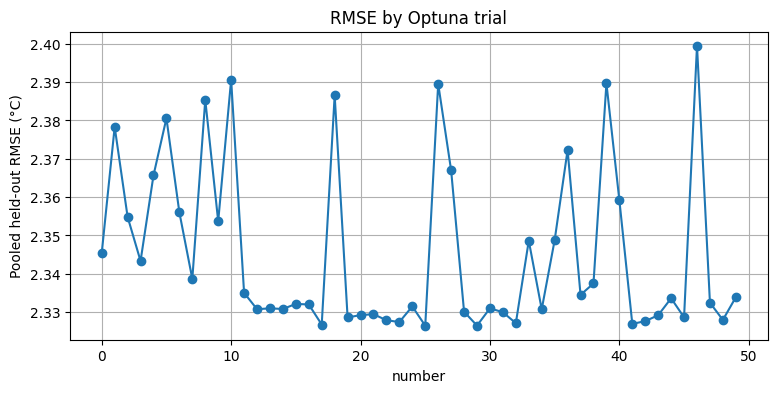

In [10]:
trials = study.trials_dataframe()
complete = trials.loc[trials['state'].astype(str) == 'COMPLETE'].copy()
display(complete.sort_values('value').head(10))
if len(complete):
    complete.plot(x='number', y='value', marker='o', legend=False, title='RMSE by Optuna trial')
    plt.ylabel('Pooled held-out RMSE (°C)')
    plt.show()

## 7. Check the held-out result and feature removal

After tuning, the least useful feature is removed only when pooled spatial RMSE stays within 0.01°C of the best all-feature score. These are model-selection results across the same five spatial folds, not a second independent test set.

In [9]:
experiment = json.loads(REPORT_OUTPUT_PATH.read_text(encoding='utf-8'))
best = experiment['bestTrial']
metrics = best['selectedFeatureMetrics']
new_metric_rows = [
    {'metric': 'Observations', 'value': f"{metrics['count']:,}"},
    {'metric': 'RMSE', 'value': f"{metrics['rmse_c']:.3f} °C"},
    {'metric': 'MAE', 'value': f"{metrics['mae_c']:.3f} °C"},
    {'metric': 'R²', 'value': f"{metrics['r2']:.3f}"},
    {'metric': 'Mean error (predicted − observed)', 'value': f"{metrics['mean_error_c']:.3f} °C"},
]
display(pd.DataFrame(new_metric_rows))
superseded = experiment.get('supersededProduction')
if superseded and superseded.get('metrics'):
    old_metrics = superseded['metrics']
    display(pd.DataFrame([
        {'feature contract': 'v4 (superseded)', 'RMSE (°C)': old_metrics['rmse_c'], 'MAE (°C)': old_metrics['mae_c'], 'R²': old_metrics['r2']},
        {'feature contract': 'v5 composite water', 'RMSE (°C)': metrics['rmse_c'], 'MAE (°C)': metrics['mae_c'], 'R²': metrics['r2']},
    ]).round(3))
    print('Traceability only: these scores use different water-feature contracts and are not a promotion test.')

fold_rows = []
for fold in best['selectedFeatureFolds']:
    fold_metrics = fold['metrics']
    fold_rows.append({
        'fold': fold['fold'],
        'observations': fold_metrics['count'],
        'best boosting round': fold['bestRound'],
        'RMSE (°C)': fold_metrics['rmse_c'],
        'MAE (°C)': fold_metrics['mae_c'],
        'R²': fold_metrics['r2'],
        'mean error (°C)': fold_metrics['mean_error_c'],
    })
display(pd.DataFrame(fold_rows).round(3))

all_feature_rmse = float(best['allFeatureRmseC'])
selection_rows = []
for decision in best['featureSelection']:
    selection_rows.append({
        'candidate feature': decision['feature'],
        'permutation importance (°C)': decision['permutationImportanceC'],
        'RMSE before removal (°C)': decision['beforeRmseC'],
        'RMSE after removal (°C)': decision['afterRmseC'],
        'change from all-feature optimum (°C)': decision['afterRmseC'] - all_feature_rmse,
        'epsilon (°C)': FEATURE_REMOVAL_TOLERANCE_C,
        'decision': 'accept removal' if decision['removed'] else 'keep feature',
    })
print(f"Feature removal tolerance: {FEATURE_REMOVAL_TOLERANCE_C:.2f} °C RMSE. A degradation at or below epsilon is accepted; a larger one is rejected.")
print(f"Selected features: {len(best['selectedFeatures'])}; rejected features: {len(best['rejectedFeatures'])}.")
display(pd.DataFrame(selection_rows).round(4))

,metric,value
0,Observations,"192,595"
1,RMSE,2.336 °C
2,MAE,1.807 °C
3,R²,0.656
4,Mean error (predicted − observed),-0.009 °C


,feature contract,RMSE (°C),MAE (°C),R²
0,v4 (superseded),2.343,1.810,0.654
1,v5 composite water,2.336,1.807,0.656


Traceability only: these scores use different water-feature contracts and are not a promotion test.


,fold,observations,best boosting round,RMSE (°C),MAE (°C),R²,mean error (°C)
0,0,38520,182,2.528,1.779,0.672,0.018
1,1,38515,111,2.521,1.959,0.594,0.467
2,2,38512,229,2.330,1.884,0.706,0.425
3,3,38522,64,2.160,1.731,0.570,0.010
4,4,38526,61,2.109,1.680,0.692,-0.965


Feature removal tolerance: 0.01 °C RMSE. A degradation at or below epsilon is accepted; a larger one is rejected.
Selected features: 34; rejected features: 66.


,candidate feature,permutation importance (°C),RMSE before removal (°C),RMSE after removal (°C),change from all-feature optimum (°C),epsilon (°C),decision
0,low_green_25_30m,-0.0081,2.3265,2.3273,0.0008,0.01,accept removal
1,low_green_50_55m,-0.0115,2.3273,2.3274,0.0010,0.01,accept removal
2,low_green_80_85m,-0.0150,2.3274,2.3273,0.0008,0.01,accept removal
3,low_green_65_70m,-0.0107,2.3273,2.3280,0.0015,0.01,accept removal
4,low_green_45_50m,-0.0107,2.3280,2.3291,0.0026,0.01,accept removal
...,...,...,...,...,...,...,...
62,agriculture_40_45m,-0.0018,2.3360,2.3358,0.0094,0.01,accept removal
63,water_40_45m,-0.0004,2.3358,2.3362,0.0097,0.01,accept removal
64,water_5_10m,-0.0001,2.3362,2.3359,0.0095,0.01,accept removal
65,agriculture_15_20m,-0.0000,2.3359,2.3361,0.0096,0.01,accept removal


In [21]:
experiment["bestTrial"]["selectedFeatures"]

['soil_sealing_0_5m',
 'soil_sealing_5_10m',
 'soil_sealing_10_15m',
 'soil_sealing_15_20m',
 'soil_sealing_20_25m',
 'soil_sealing_25_30m',
 'soil_sealing_30_35m',
 'soil_sealing_35_40m',
 'soil_sealing_40_45m',
 'soil_sealing_45_50m',
 'soil_sealing_50_55m',
 'soil_sealing_55_60m',
 'soil_sealing_60_65m',
 'soil_sealing_65_70m',
 'soil_sealing_70_75m',
 'soil_sealing_75_80m',
 'soil_sealing_80_85m',
 'soil_sealing_85_90m',
 'soil_sealing_90_95m',
 'soil_sealing_95_100m',
 'high_green_0_5m',
 'high_green_15_20m',
 'high_green_85_90m',
 'high_green_90_95m',
 'high_green_95_100m',
 'low_green_95_100m',
 'agriculture_0_5m',
 'agriculture_10_15m',
 'agriculture_20_25m',
 'agriculture_95_100m',
 'water_0_5m',
 'water_50_55m',
 'water_55_60m',
 'water_95_100m']

### IMPORTANCE NOTICE : RETUNING AFTER FEATURE REMOVAL WOULD BE THE RIGHT THING TO DO, NOT CURRENTLY DONE FOR THIS FIRST POC

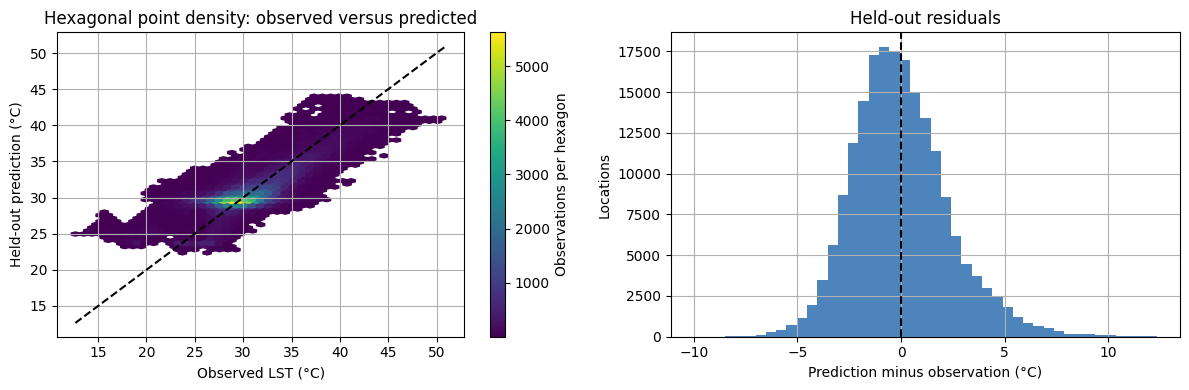

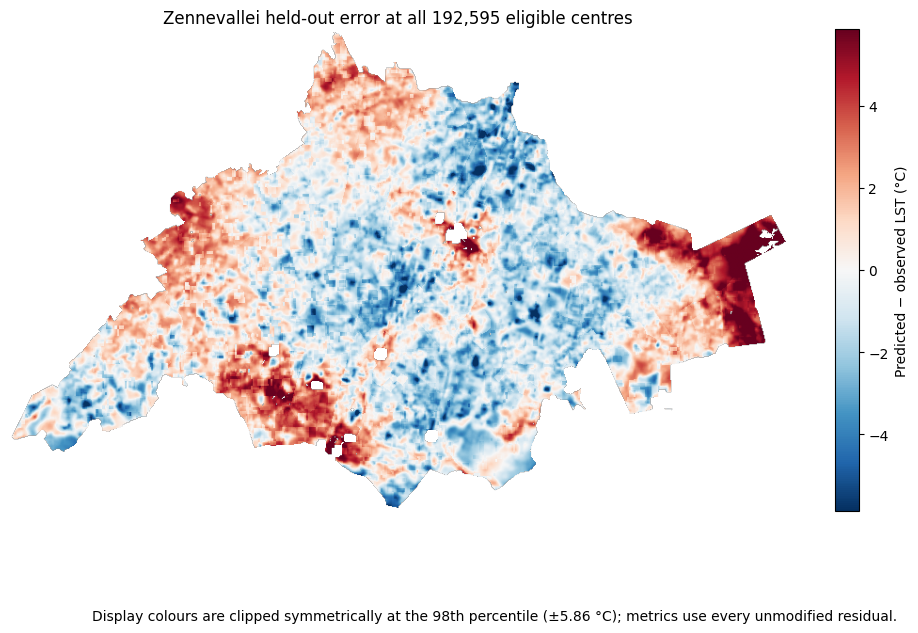

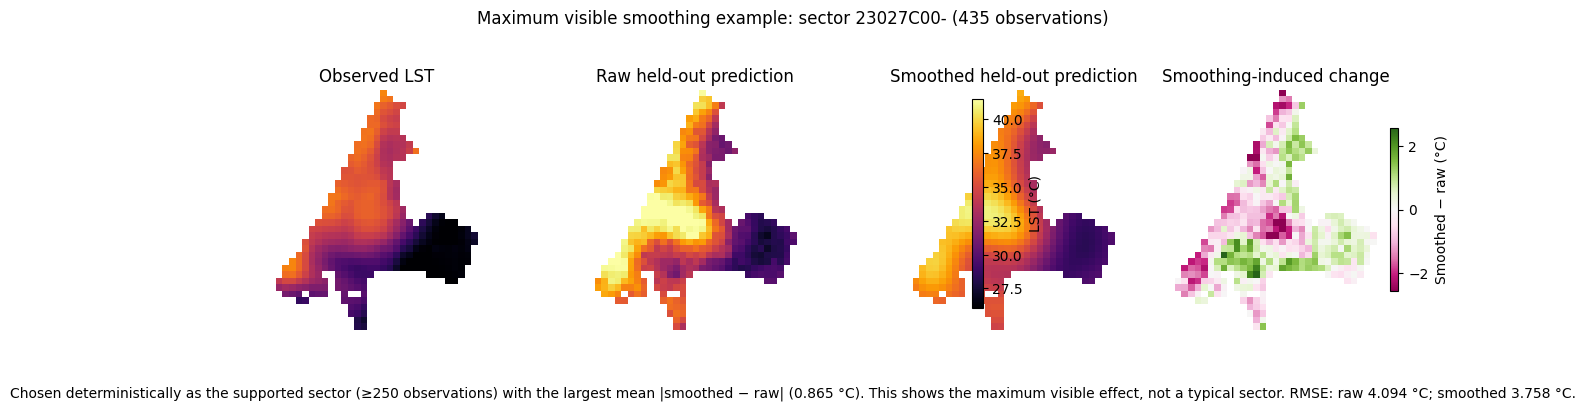

In [12]:
diagnostic_path = prepare_notebook_diagnostics(catalog)
with np.load(diagnostic_path, allow_pickle=False) as diagnostic:
    observed = diagnostic['observed_c'].copy()
    raw_predicted = diagnostic['predicted_raw_c'].copy()
    smoothed_predicted = diagnostic['predicted_smoothed_c'].copy()
    residual = diagnostic['residual_c'].copy()
    raster_rows = diagnostic['landsat_rows'].copy()
    raster_columns = diagnostic['landsat_columns'].copy()
    sector_ids = diagnostic['sector_ids'].astype(str)
    fold_ids = diagnostic['fold_ids'].copy()
assert np.isfinite(np.column_stack([observed, raw_predicted, smoothed_predicted, residual])).all()
assert np.allclose(residual, smoothed_predicted - observed)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
hexagons = axes[0].hexbin(observed, smoothed_predicted, gridsize=45, mincnt=1, cmap='viridis')
hexagon_bar = figure.colorbar(hexagons, ax=axes[0])
hexagon_bar.set_label('Observations per hexagon')
minimum = float(min(observed.min(), smoothed_predicted.min()))
maximum = float(max(observed.max(), smoothed_predicted.max()))
axes[0].plot([minimum, maximum], [minimum, maximum], color='black', linestyle='--')
axes[0].set(xlabel='Observed LST (°C)', ylabel='Held-out prediction (°C)', title='Hexagonal point density: observed versus predicted')
axes[1].hist(residual, bins=45, color='#2166ac', alpha=.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Prediction minus observation (°C)', ylabel='Locations', title='Held-out residuals')
plt.tight_layout()
plt.show()

grid_shape = (int(raster_rows.max()) + 1, int(raster_columns.max()) + 1)
residual_grid = np.full(grid_shape, np.nan, dtype=np.float32)
residual_grid[raster_rows, raster_columns] = residual
residual_limit = float(np.quantile(np.abs(residual), .98))
figure, axis = plt.subplots(figsize=(10, 7))
residual_image = axis.imshow(
    residual_grid, cmap='RdBu_r',
    norm=TwoSlopeNorm(vmin=-residual_limit, vcenter=0, vmax=residual_limit),
)
axis.set_title(f'Zennevallei held-out error at all {len(residual):,} eligible centres')
axis.set_axis_off()
residual_bar = figure.colorbar(residual_image, ax=axis, shrink=.75)
residual_bar.set_label('Predicted − observed LST (°C)')
figure.text(.5, .02, f'Display colours are clipped symmetrically at the 98th percentile (±{residual_limit:.2f} °C); metrics use every unmodified residual.', ha='center')
plt.tight_layout(rect=(0, .04, 1, 1))
plt.show()

smoothing_example = select_smoothing_example_sector(sector_ids, raw_predicted, smoothed_predicted, minimum_observations=250)
sector_mask = sector_ids == smoothing_example['sectorId']
sector_rows, sector_columns = raster_rows[sector_mask], raster_columns[sector_mask]
row_min, row_max = int(sector_rows.min()), int(sector_rows.max())
column_min, column_max = int(sector_columns.min()), int(sector_columns.max())

def sector_grid(values):
    grid = np.full((row_max - row_min + 1, column_max - column_min + 1), np.nan, dtype=np.float32)
    grid[sector_rows - row_min, sector_columns - column_min] = values[sector_mask]
    return grid

temperature_values = np.concatenate([observed[sector_mask], raw_predicted[sector_mask], smoothed_predicted[sector_mask]])
temperature_min, temperature_max = np.quantile(temperature_values, [.02, .98])
smoothing_change = smoothed_predicted - raw_predicted
change_limit = float(np.quantile(np.abs(smoothing_change[sector_mask]), .98))
raw_sector_rmse = float(np.sqrt(np.mean((raw_predicted[sector_mask] - observed[sector_mask]) ** 2)))
smoothed_sector_rmse = float(np.sqrt(np.mean((smoothed_predicted[sector_mask] - observed[sector_mask]) ** 2)))
figure, axes = plt.subplots(1, 4, figsize=(16, 4))
for axis, title, values in zip(
    axes[:3],
    ['Observed LST', 'Raw held-out prediction', 'Smoothed held-out prediction'],
    [observed, raw_predicted, smoothed_predicted],
):
    temperature_image = axis.imshow(sector_grid(values), cmap='inferno', vmin=temperature_min, vmax=temperature_max)
    axis.set_title(title)
    axis.set_axis_off()
change_image = axes[3].imshow(
    sector_grid(smoothing_change), cmap='PiYG',
    norm=TwoSlopeNorm(vmin=-change_limit, vcenter=0, vmax=change_limit),
)
axes[3].set_title('Smoothing-induced change')
axes[3].set_axis_off()
figure.colorbar(temperature_image, ax=axes[:3], shrink=.68, label='LST (°C)')
figure.colorbar(change_image, ax=axes[3], shrink=.68, label='Smoothed − raw (°C)')
figure.suptitle(f"Maximum visible smoothing example: sector {smoothing_example['sectorId']} ({smoothing_example['observationCount']:,} observations)")
figure.text(
    .5, .01,
    f"Chosen deterministically as the supported sector (≥250 observations) with the largest mean |smoothed − raw| ({smoothing_example['meanAbsoluteChangeC']:.3f} °C). "
    f"This shows the maximum visible effect, not a typical sector. RMSE: raw {raw_sector_rmse:.3f} °C; smoothed {smoothed_sector_rmse:.3f} °C.",
    ha='center',
)
figure.subplots_adjust(top=.78, bottom=.18, wspace=.12)
plt.show()

## 8. Check that the live tool uses one consistent training run

A hash is simply a file fingerprint. If a catalogue, model, feature definition, or baseline grid came from another run, its fingerprint would differ and the live tool would refuse to combine the files. The table below turns those checks into plain pass/fail results.

Scenario ΔLST is always `modified prediction − this model's own baseline prediction`. Mark sizes, map opacity, and smoothing are presentation or prediction-stabilisation choices, not statistical weights.

In [13]:
production = json.loads(DEFAULT_ARTIFACTS.report.read_text(encoding='utf-8'))
catalogue_fingerprint = file_hash(catalog.cache_dir / 'manifest.json')
model_fingerprint = file_hash(DEFAULT_ARTIFACTS.model)
feature_fingerprint = file_hash(DEFAULT_ARTIFACTS.features)
baseline_fingerprint = file_hash(DEFAULT_ARTIFACTS.inference_grid)
checks = [
    {'file or contract': 'Feature contract', 'status': production['modelContractVersion'] == FEATURE_CONTRACT_VERSION, 'fingerprint': f'contract {FEATURE_CONTRACT_VERSION}'},
    {'file or contract': 'Training catalogue', 'status': production['catalogManifestSha256'] == catalogue_fingerprint, 'fingerprint': catalogue_fingerprint[:12]},
    {'file or contract': 'Retained-feature artifact', 'status': production['featureArtifactSha256'] == feature_fingerprint, 'fingerprint': feature_fingerprint[:12]},
    {'file or contract': 'XGBoost model', 'status': production['final']['modelSha256'] == model_fingerprint, 'fingerprint': model_fingerprint[:12]},
    {'file or contract': 'Baseline inference grid', 'status': production['inferenceGrid']['sha256'] == baseline_fingerprint, 'fingerprint': baseline_fingerprint[:12]},
]
assert all(check['status'] for check in checks)
display(pd.DataFrame([{**check, 'status': 'PASS' if check['status'] else 'FAIL'} for check in checks]))

summary = {
    'model name': '2026 Heatwave XGBoost',
    'target': production['observationId'],
    'samples': f"{production['sampleCount']:,}",
    'sectors': production['sectorCount'],
    'held-out RMSE': f"{production['pooledOuterMetrics']['rmse_c']:.3f} °C",
    'held-out R²': f"{production['pooledOuterMetrics']['r2']:.3f}",
    'ring width': f"{production['final']['ringWidthMeters']} m",
    'smoothing sigma': f"{production['final']['smoothingSigmaMeters']} m",
    'retained features': len(production['final']['retainedFeatures']),
}
display(pd.Series(summary, name='verified production result').to_frame())

,file or contract,status,fingerprint
0,Feature contract,PASS,contract 5
1,Training catalogue,PASS,026cdc8975d9
2,Retained-feature artifact,PASS,ab65eba0cf87
3,XGBoost model,PASS,7aab4f678d10
4,Baseline inference grid,PASS,20a07476475b


,verified production result
model name,2026 Heatwave XGBoost
target,landsat-2026-06-22
samples,"192,595"
sectors,154
held-out RMSE,2.336 °C
held-out R²,0.656
ring width,5 m
smoothing sigma,60 m
retained features,34


## 9. Next steps;

strengthen pipeline (tuning/features_removal)

investigate building geometric/height features

expand training data to new areas surrounding zennevallei